## TBATS–Prophet Hybrid Forecasting  
### Step 1 — Data Preparation and Forecasting Contract

Before estimating the hybrid forecasting models, the dataset must be prepared to ensure full consistency with the SARIMA benchmark framework.

This step establishes a standardized forecasting contract that will be used by both TBATS and Prophet models.

The preparation process performs the following tasks:

1. Create a working dataset that includes the key labour market variables:
   - unemployment
   - vacancies
   - labour market tightness (θ)

2. Generate log-transformed series for unemployment and vacancies.  
   Log transformation stabilizes variance and ensures comparability with the SARIMA models estimated earlier.

3. Define the locked **training and testing split**, which must remain identical across all forecasting models to allow fair performance comparison.

4. Prepare Prophet-compatible datasets, which require a specific structure:
   - `ds` (timestamp column)
   - `y` (target variable)

5. Verify that all series are aligned in time and contain no missing observations.

This step ensures that the TBATS and Prophet models operate on the same forecasting framework used by the SARIMA benchmark.

In [4]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
UTILS_PATH = PROJECT_ROOT / "4_predictive_forecasting" / "utils"

sys.path.append(str(UTILS_PATH))

from data_loader import load_dataset

df = load_dataset()

df.head()


Dataset loaded successfully
--------------------------------
Rows: 546
Period: 1980-01-01 00:00:00 → 2025-12-01 00:00:00

Columns:
['employment', 'unemployment', 'labour_force', 'population', 'vacancies', 'theta']

Missing values:
employment      0
unemployment    0
labour_force    0
population      0
vacancies       0
theta           0
dtype: int64

Summary statistics:
        employment  unemployment  labour_force   population   vacancies  \
count       546.00        546.00        546.00       546.00      546.00   
mean   15373110.07    1299307.33   16672417.40  25238762.27   305316.43   
std     2902418.85     190657.59    2919465.16   4371584.60   182311.44   
min    10764100.00     857700.00   11760100.00  18317900.00    90204.00   
25%    12855650.00    1145275.00   14299250.00  21508550.00   181225.00   
50%    15413000.00    1299400.00   16675800.00  24856950.00   241145.50   
75%    17690325.00    1426800.00   19051150.00  28712150.00   360527.00   
max    21146000.00    1863

,employment,unemployment,labour_force,population,vacancies,theta
month,,,,,,
1980-01-01,10882600,877500,11760100,18317900,273345.0,0.311504
1980-02-01,10902900,894000,11796900,18346400,259678.0,0.290468
1980-03-01,10897800,901000,11798800,18373900,254211.0,0.282143
1980-04-01,10938300,908300,11846600,18407700,256944.0,0.282885
1980-05-01,10891600,923900,11815500,18437000,235077.0,0.254440


In [5]:
# =========================================================
# STEP 1B — DATA PREPARATION
# =========================================================

import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. Verify time index
# ---------------------------------------------------------

print("Index type:", type(df.index))
print("Date range:", df.index.min(), "to", df.index.max())
print("Total observations:", len(df))


# ---------------------------------------------------------
# 2. Create log variables
# ---------------------------------------------------------

df["log_unemployment"] = np.log(df["unemployment"])
df["log_vacancies"] = np.log(df["vacancies"])

print("Log variables created.")


# ---------------------------------------------------------
# 3. Train / Test split
# ---------------------------------------------------------

TRAIN_END = "2022-12-01"
TEST_START = "2023-01-01"

train = df.loc[:TRAIN_END].copy()
test = df.loc[TEST_START:].copy()

print("\nTrain size:", len(train))
print("Test size:", len(test))

print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())


# ---------------------------------------------------------
# 4. Prepare Prophet datasets
# Prophet requires columns: ds, y
# ---------------------------------------------------------

prophet_unemployment = train.reset_index()[["month", "log_unemployment"]]
prophet_unemployment.columns = ["ds", "y"]

prophet_vacancies = train.reset_index()[["month", "log_vacancies"]]
prophet_vacancies.columns = ["ds", "y"]

print("\nProphet datasets prepared.")


# ---------------------------------------------------------
# 5. Check missing values
# ---------------------------------------------------------

print("\nMissing values in train:")
print(train.isna().sum())

print("\nMissing values in test:")
print(test.isna().sum())

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Date range: 1980-01-01 00:00:00 to 2025-12-01 00:00:00
Total observations: 546
Log variables created.

Train size: 510
Test size: 36
Train period: 1980-01-01 00:00:00 to 2022-12-01 00:00:00
Test period: 2023-01-01 00:00:00 to 2025-12-01 00:00:00

Prophet datasets prepared.

Missing values in train:
employment          0
unemployment        0
labour_force        0
population          0
vacancies           0
theta               0
log_unemployment    0
log_vacancies       0
dtype: int64

Missing values in test:
employment          0
unemployment        0
labour_force        0
population          0
vacancies           0
theta               0
log_unemployment    0
log_vacancies       0
dtype: int64


### Step 2 — TBATS Model Estimation

This step estimates TBATS models for unemployment and vacancy series.

TBATS (Trigonometric seasonality, Box-Cox transformation, ARMA errors, Trend, and Seasonal components) is designed for time series with:

* complex seasonal structure
* non-linear cyclical behavior
* damped trends

The model is particularly useful for labor-market series where hiring patterns often exhibit seasonal fluctuations.

Two TBATS models are estimated separately:

1. Log unemployment
2. Log vacancies

Both models are trained using the training dataset and generate forecasts for the testing period.

These TBATS forecasts will later be combined with Prophet forecasts to construct the hybrid forecasting model.


In [6]:
# =========================================================
# STEP 2 — TBATS MODEL ESTIMATION
# =========================================================

from tbats import TBATS

# ---------------------------------------------------------
# 1. Define forecast horizon
# ---------------------------------------------------------

h = len(test)

print("Forecast horizon:", h)


# ---------------------------------------------------------
# 2. Prepare training series
# ---------------------------------------------------------

y_train_u = train["log_unemployment"].values
y_train_v = train["log_vacancies"].values


# ---------------------------------------------------------
# 3. Fit TBATS model for unemployment
# ---------------------------------------------------------

tbats_estimator = TBATS(seasonal_periods=[12])

tbats_u = tbats_estimator.fit(y_train_u)

print("TBATS unemployment model fitted.")


# ---------------------------------------------------------
# 4. Fit TBATS model for vacancies
# ---------------------------------------------------------

tbats_v = tbats_estimator.fit(y_train_v)

print("TBATS vacancies model fitted.")


# ---------------------------------------------------------
# 5. Generate forecasts
# ---------------------------------------------------------

tbats_forecast_u = tbats_u.forecast(steps=h)
tbats_forecast_v = tbats_v.forecast(steps=h)


# ---------------------------------------------------------
# 6. Convert forecasts to pandas series
# ---------------------------------------------------------

tbats_forecast_u = pd.Series(tbats_forecast_u, index=test.index)
tbats_forecast_v = pd.Series(tbats_forecast_v, index=test.index)


# ---------------------------------------------------------
# 7. Store results
# ---------------------------------------------------------

test["tbats_log_unemployment_forecast"] = tbats_forecast_u
test["tbats_log_vacancies_forecast"] = tbats_forecast_v

print("TBATS forecasts stored in test dataset.")


# ---------------------------------------------------------
# 8. Quick preview
# ---------------------------------------------------------

test[[
    "log_unemployment",
    "tbats_log_unemployment_forecast",
    "log_vacancies",
    "tbats_log_vacancies_forecast"
]].head()

Forecast horizon: 36


c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


TBATS unemployment model fitted.


c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


TBATS vacancies model fitted.
TBATS forecasts stored in test dataset.


c:\Users\Anurodh\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,log_unemployment,tbats_log_unemployment_forecast,log_vacancies,tbats_log_vacancies_forecast
month,,,,
2023-01-01,13.895892,13.86457,13.577609,13.550213
2023-02-01,13.907451,13.86457,13.524784,13.550250
2023-03-01,13.891731,13.86457,13.580256,13.559799
2023-04-01,13.893120,13.86457,13.641098,13.570324
2023-05-01,13.921041,13.86457,13.607884,13.543667


### Step 3 — Prophet Model Estimation

This stage estimates Prophet models for unemployment and vacancy series.

Prophet is a decomposable time-series model that represents a series as the sum of:

* a piecewise linear trend
* seasonal components
* stochastic residual variation

Unlike SARIMA or TBATS, Prophet is specifically designed to handle:

* structural trend changes
* non-linear growth patterns
* regime shifts

This capability is particularly useful when modeling labour market dynamics that may experience abrupt changes due to macroeconomic shocks.

Two Prophet models are estimated separately:

1. Log unemployment
2. Log vacancies

The models are trained using the training dataset and produce forecasts for the testing period.

These forecasts will later be combined with TBATS forecasts to construct the hybrid forecasting model.


In [7]:
# =========================================================
# STEP 3 — PROPHET MODEL ESTIMATION
# =========================================================

from prophet import Prophet

# ---------------------------------------------------------
# 1. Prepare Prophet datasets
# ---------------------------------------------------------

prophet_u = train.reset_index()[["month", "log_unemployment"]]
prophet_u.columns = ["ds", "y"]

prophet_v = train.reset_index()[["month", "log_vacancies"]]
prophet_v.columns = ["ds", "y"]

print("Prophet datasets prepared.")


# ---------------------------------------------------------
# 2. Fit Prophet model — unemployment
# ---------------------------------------------------------

model_prophet_u = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet_u.fit(prophet_u)

print("Prophet unemployment model fitted.")


# ---------------------------------------------------------
# 3. Fit Prophet model — vacancies
# ---------------------------------------------------------

model_prophet_v = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet_v.fit(prophet_v)

print("Prophet vacancies model fitted.")


# ---------------------------------------------------------
# 4. Create future dataframe for forecasting
# ---------------------------------------------------------

future_dates = pd.DataFrame({"ds": test.index})


# ---------------------------------------------------------
# 5. Generate forecasts
# ---------------------------------------------------------

forecast_prophet_u = model_prophet_u.predict(future_dates)
forecast_prophet_v = model_prophet_v.predict(future_dates)


# ---------------------------------------------------------
# 6. Extract predictions
# ---------------------------------------------------------

prophet_forecast_u = pd.Series(
    forecast_prophet_u["yhat"].values,
    index=test.index
)

prophet_forecast_v = pd.Series(
    forecast_prophet_v["yhat"].values,
    index=test.index
)


# ---------------------------------------------------------
# 7. Store forecasts
# ---------------------------------------------------------

test["prophet_log_unemployment_forecast"] = prophet_forecast_u
test["prophet_log_vacancies_forecast"] = prophet_forecast_v

print("Prophet forecasts stored in test dataset.")


# ---------------------------------------------------------
# 8. Preview results
# ---------------------------------------------------------

test[[
    "log_unemployment",
    "tbats_log_unemployment_forecast",
    "prophet_log_unemployment_forecast",
    "log_vacancies",
    "tbats_log_vacancies_forecast",
    "prophet_log_vacancies_forecast"
]].head()

Prophet datasets prepared.


15:36:21 - cmdstanpy - INFO - Chain [1] start processing
15:36:22 - cmdstanpy - INFO - Chain [1] done processing
15:36:22 - cmdstanpy - INFO - Chain [1] start processing


Prophet unemployment model fitted.


15:36:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet vacancies model fitted.
Prophet forecasts stored in test dataset.


,log_unemployment,tbats_log_unemployment_forecast,prophet_log_unemployment_forecast,log_vacancies,tbats_log_vacancies_forecast,prophet_log_vacancies_forecast
month,,,,,,
2023-01-01,13.895892,13.86457,14.028473,13.577609,13.550213,13.751209
2023-02-01,13.907451,13.86457,14.025438,13.524784,13.550250,13.751423
2023-03-01,13.891731,13.86457,14.030322,13.580256,13.559799,13.787662
2023-04-01,13.893120,13.86457,14.028679,13.641098,13.570324,13.863481
2023-05-01,13.921041,13.86457,14.016221,13.607884,13.543667,13.863534


### Step 4 — TBATS–Prophet Hybrid Forecast Construction

This step constructs the hybrid forecast by combining predictions from the TBATS and Prophet models.

The hybrid approach leverages the complementary strengths of both models:

* TBATS captures cyclical and seasonal patterns.
* Prophet captures structural trend shifts.

The hybrid forecast is defined as the average of the two model forecasts:

[
\hat{y}*{t}^{hybrid} = \frac{\hat{y}*{t}^{TBATS} + \hat{y}_{t}^{Prophet}}{2}
]

This combination reduces model-specific bias and often improves forecast stability.

Because both models were estimated on log-transformed variables, forecasts must be transformed back to levels using the exponential function.

Once unemployment and vacancy forecasts are converted to levels, labour market tightness is derived as:

[
\hat{\theta}_t = \frac{\hat{V}_t}{\hat{U}_t}
]

This produces the hybrid forecasts for the three key variables used in the labor market analysis:

* unemployment
* job vacancies
* labour market tightness


In [8]:
# =========================================================
# STEP 4 — TBATS + PROPHET HYBRID FORECAST
# =========================================================

import numpy as np
import pandas as pd


# ---------------------------------------------------------
# 1. Hybrid forecasts (log scale)
# ---------------------------------------------------------

test["hybrid_log_unemployment"] = (
    test["tbats_log_unemployment_forecast"] +
    test["prophet_log_unemployment_forecast"]
) / 2

test["hybrid_log_vacancies"] = (
    test["tbats_log_vacancies_forecast"] +
    test["prophet_log_vacancies_forecast"]
) / 2


# ---------------------------------------------------------
# 2. Convert forecasts back to levels
# ---------------------------------------------------------

test["hybrid_unemployment"] = np.exp(test["hybrid_log_unemployment"])
test["hybrid_vacancies"] = np.exp(test["hybrid_log_vacancies"])


# ---------------------------------------------------------
# 3. Compute hybrid tightness
# ---------------------------------------------------------

test["hybrid_theta"] = (
    test["hybrid_vacancies"] /
    test["hybrid_unemployment"]
)


# ---------------------------------------------------------
# 4. Also compute actual theta for comparison
# ---------------------------------------------------------

test["actual_theta"] = (
    test["vacancies"] /
    test["unemployment"]
)


# ---------------------------------------------------------
# 5. Quick preview
# ---------------------------------------------------------

test[[
    "unemployment",
    "hybrid_unemployment",
    "vacancies",
    "hybrid_vacancies",
    "actual_theta",
    "hybrid_theta"
]].head()

,unemployment,hybrid_unemployment,vacancies,hybrid_vacancies,actual_theta,hybrid_theta
month,,,,,,
2023-01-01,1083700,1.139981e+06,788280.0,848063.590073,0.727397,0.743928
2023-02-01,1096300,1.138252e+06,747720.0,848170.164713,0.682040,0.745152
2023-03-01,1079200,1.141035e+06,790370.0,867811.837645,0.732367,0.760548
2023-04-01,1080700,1.140098e+06,839950.0,906097.982616,0.777228,0.794754
2023-05-01,1111300,1.133018e+06,812510.0,894124.491141,0.731135,0.789153


### Step 5 — Forecast Accuracy Evaluation

This step evaluates the performance of the hybrid forecasts generated from the TBATS–Prophet ensemble model.

Forecast accuracy is assessed using three widely used metrics:

* **Mean Absolute Error (MAE)** — measures the average magnitude of forecast errors.
* **Root Mean Squared Error (RMSE)** — penalizes larger forecast errors more strongly.
* **Mean Absolute Percentage Error (MAPE)** — expresses forecast error relative to the observed values.

These metrics are computed for the three key labour market variables:

1. unemployment
2. job vacancies
3. labour market tightness (θ)

Evaluating forecasts across multiple metrics provides a more robust assessment of model performance and allows comparison with alternative forecasting approaches implemented later in the analysis pipeline.


In [9]:
# =========================================================
# STEP 5 — FORECAST ERROR METRICS
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ---------------------------------------------------------
# 1. Define evaluation function
# ---------------------------------------------------------

def forecast_metrics(actual, forecast):

    mae = mean_absolute_error(actual, forecast)
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return mae, rmse, mape


# ---------------------------------------------------------
# 2. Compute metrics — unemployment
# ---------------------------------------------------------

mae_u, rmse_u, mape_u = forecast_metrics(
    test["unemployment"],
    test["hybrid_unemployment"]
)


# ---------------------------------------------------------
# 3. Compute metrics — vacancies
# ---------------------------------------------------------

mae_v, rmse_v, mape_v = forecast_metrics(
    test["vacancies"],
    test["hybrid_vacancies"]
)


# ---------------------------------------------------------
# 4. Compute metrics — labour tightness
# ---------------------------------------------------------

mae_t, rmse_t, mape_t = forecast_metrics(
    test["actual_theta"],
    test["hybrid_theta"]
)


# ---------------------------------------------------------
# 5. Create results table
# ---------------------------------------------------------

results = pd.DataFrame({

    "Variable": [
        "Unemployment",
        "Vacancies",
        "Tightness (Theta)"
    ],

    "MAE": [
        mae_u,
        mae_v,
        mae_t
    ],

    "RMSE": [
        rmse_u,
        rmse_v,
        rmse_t
    ],

    "MAPE (%)": [
        mape_u,
        mape_v,
        mape_t
    ]

})


print("\nHybrid Model Forecast Accuracy\n")
display(results)


Hybrid Model Forecast Accuracy



,Variable,MAE,RMSE,MAPE (%)
0,Unemployment,253784.928099,298982.684360,17.329632
1,Vacancies,362584.319804,401842.469364,67.527535
2,Tightness (Theta),0.397055,0.447494,109.124350


### Step 6 — Forecast Visualization

Visual inspection of forecasts is an important complement to numerical accuracy metrics.

While metrics such as MAE and RMSE summarize overall forecast performance, they do not reveal how forecasts behave over time. Visualization allows us to examine whether the model:

* tracks the direction of the series
* captures turning points
* systematically over- or under-predicts
* produces excessively smooth forecasts

Three forecast comparison plots are generated:

1. **Unemployment:** actual vs hybrid forecast
2. **Job vacancies:** actual vs hybrid forecast
3. **Labour market tightness (θ):** actual vs hybrid forecast

These visual diagnostics provide additional insight into the forecasting performance of the TBATS–Prophet hybrid model.


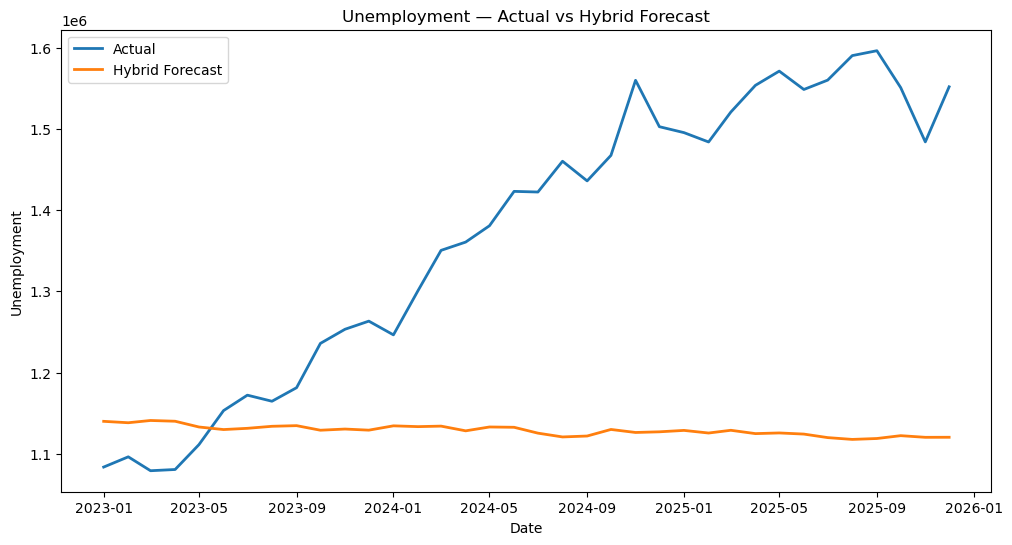

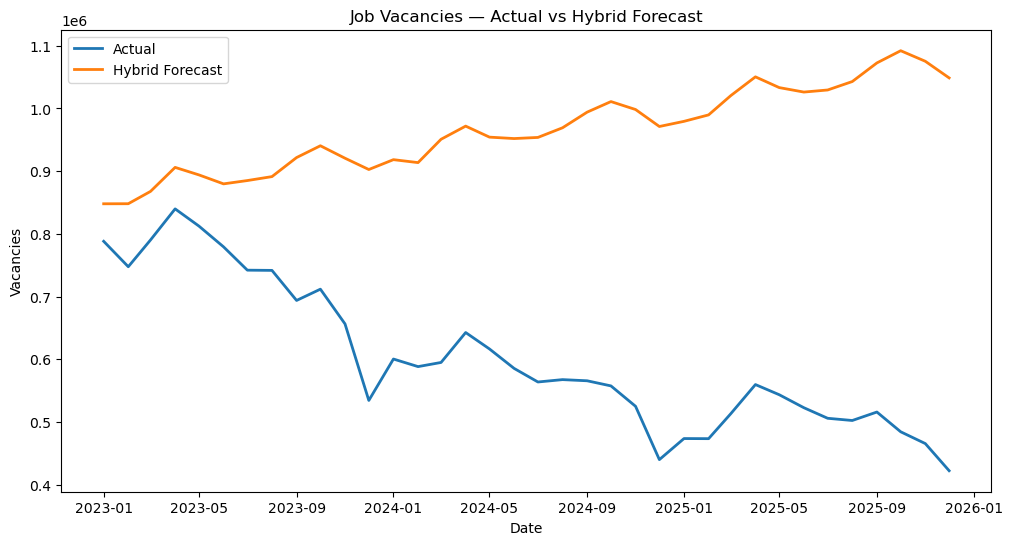

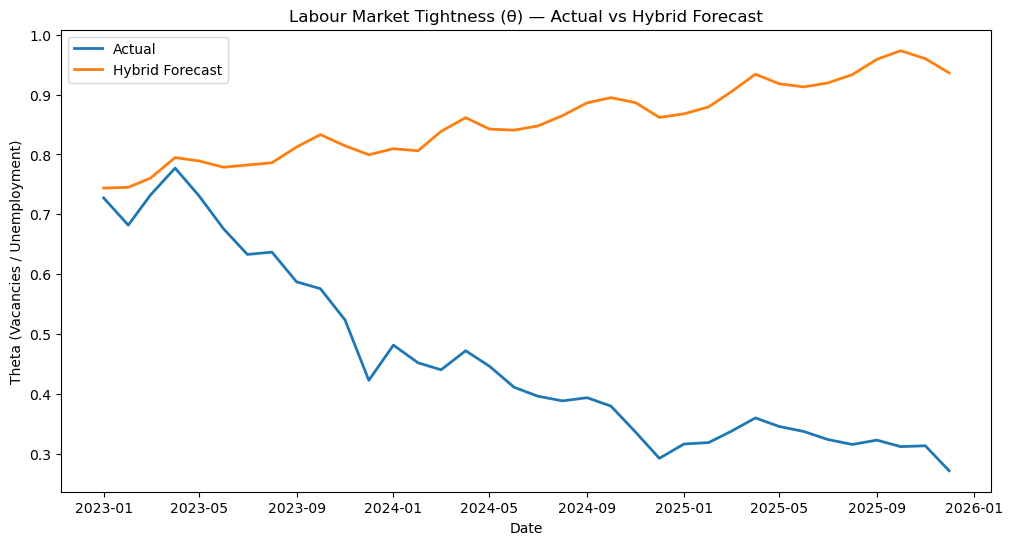

In [10]:
# =========================================================
# STEP 6 — FORECAST VISUALIZATION
# =========================================================

import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Unemployment forecast
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(test.index, test["unemployment"], label="Actual", linewidth=2)
plt.plot(test.index, test["hybrid_unemployment"], label="Hybrid Forecast", linewidth=2)

plt.title("Unemployment — Actual vs Hybrid Forecast")
plt.xlabel("Date")
plt.ylabel("Unemployment")
plt.legend()

plt.show()


# ---------------------------------------------------------
# 2. Vacancies forecast
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(test.index, test["vacancies"], label="Actual", linewidth=2)
plt.plot(test.index, test["hybrid_vacancies"], label="Hybrid Forecast", linewidth=2)

plt.title("Job Vacancies — Actual vs Hybrid Forecast")
plt.xlabel("Date")
plt.ylabel("Vacancies")
plt.legend()

plt.show()


# ---------------------------------------------------------
# 3. Labour market tightness
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

plt.plot(test.index, test["actual_theta"], label="Actual", linewidth=2)
plt.plot(test.index, test["hybrid_theta"], label="Hybrid Forecast", linewidth=2)

plt.title("Labour Market Tightness (θ) — Actual vs Hybrid Forecast")
plt.xlabel("Date")
plt.ylabel("Theta (Vacancies / Unemployment)")
plt.legend()

plt.show()

Train: (510, 6)
Test : (36, 6)


19:07:42 - cmdstanpy - INFO - Chain [1] start processing
19:07:42 - cmdstanpy - INFO - Chain [1] done processing


,actual_unemployment,forecast_unemployment,actual_vacancies,forecast_vacancies,actual_theta,forecast_theta
month,,,,,,
2023-01-01,1083700,1.050283e+06,788280.0,814798.768799,0.727397,0.775790
2023-02-01,1096300,1.050283e+06,747720.0,817307.198041,0.682040,0.778178
2023-03-01,1079200,1.050283e+06,790370.0,829715.798938,0.732367,0.789993
2023-04-01,1080700,1.050283e+06,839950.0,858769.783616,0.777228,0.817656
2023-05-01,1111300,1.050283e+06,812510.0,861678.767158,0.731135,0.820425



Metrics


,model,target,RMSE,MAE,MAPE,sMAPE,MASE
0,TBATS_PROPHET,unemployment,362581.814030,318883.537045,21.978929,25.445663,10.916397
1,TBATS_PROPHET,vacancies,358529.733237,318636.215093,59.731774,42.798329,10.128067
2,TBATS_PROPHET,theta,0.463384,0.418787,113.813953,65.218235,14.705638


,model_name,target,origin_date,train_end_date,forecast_date,forecast_horizon,predicted_value,actual_value
month,,,,,,,,
2023-01-01,TBATS_PROPHET,unemployment,2022-12-01,2022-12-01,2023-01-01,1,1.050283e+06,1083700.0
2023-02-01,TBATS_PROPHET,unemployment,2022-12-01,2022-12-01,2023-02-01,2,1.050283e+06,1096300.0
2023-03-01,TBATS_PROPHET,unemployment,2022-12-01,2022-12-01,2023-03-01,3,1.050283e+06,1079200.0
2023-04-01,TBATS_PROPHET,unemployment,2022-12-01,2022-12-01,2023-04-01,4,1.050283e+06,1080700.0
2023-05-01,TBATS_PROPHET,unemployment,2022-12-01,2022-12-01,2023-05-01,5,1.050283e+06,1111300.0


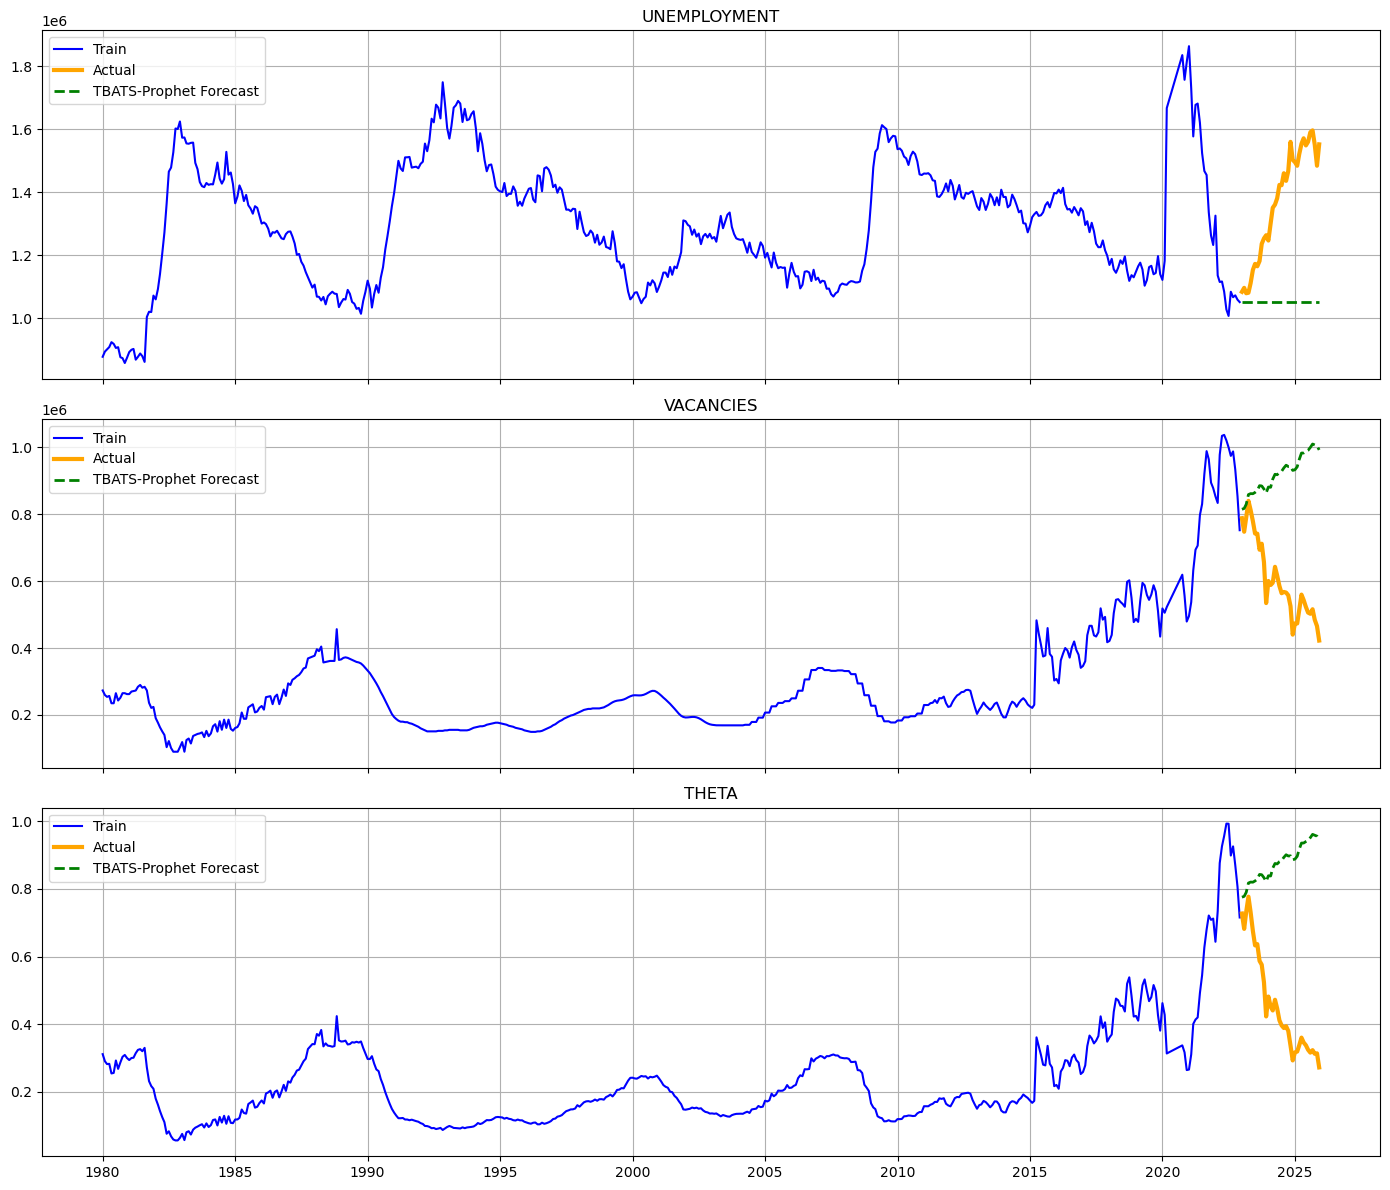


TBATS-Prophet freeze completed.


In [11]:
# ============================================================
# STEP S10–S11 — FROZEN TBATS-PROPHET HOLDOUT FORECAST,
# METRICS, EXPORT, AND VISUAL DIAGNOSTICS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------
MODEL_NAME = "TBATS_PROPHET"
TRAIN_END = "2022-12-01"
TEST_START = "2023-01-01"

# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------
from data_loader import load_dataset
df = load_dataset(verbose=False).copy()

df.index = pd.to_datetime(df.index)
df = df.sort_index()

train = df.loc[:TRAIN_END].copy()
test = df.loc[TEST_START:].copy()

print("Train:", train.shape)
print("Test :", test.shape)

# ------------------------------------------------------------
# TBATS forecast for unemployment
# ------------------------------------------------------------
from tbats import TBATS

tbats_estimator = TBATS(seasonal_periods=[12])

u_model = tbats_estimator.fit(train["unemployment"].values)

u_forecast = u_model.forecast(steps=len(test))
u_forecast = pd.Series(u_forecast, index=test.index)

# ------------------------------------------------------------
# Prophet forecast for vacancies
# ------------------------------------------------------------
from prophet import Prophet

vac_df = train.reset_index()[["month","vacancies"]]
vac_df.columns = ["ds","y"]

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(vac_df)

future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="MS"
)

forecast = prophet_model.predict(future)

v_forecast = forecast.set_index("ds")["yhat"].loc[test.index]

# ------------------------------------------------------------
# Theta forecast
# ------------------------------------------------------------
theta_forecast = v_forecast / u_forecast

# ------------------------------------------------------------
# Build results table
# ------------------------------------------------------------
results = pd.DataFrame(index=test.index)

results["actual_unemployment"] = test["unemployment"]
results["forecast_unemployment"] = u_forecast

results["actual_vacancies"] = test["vacancies"]
results["forecast_vacancies"] = v_forecast

results["actual_theta"] = test["theta"]
results["forecast_theta"] = theta_forecast

display(results.head())

# ------------------------------------------------------------
# Metrics (safe)
# ------------------------------------------------------------
def clean_metric_inputs(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = (~np.isnan(y_true)) & (~np.isnan(y_pred))

    return y_true[mask], y_pred[mask]


def mape(y_true, y_pred):

    y_true, y_pred = clean_metric_inputs(y_true, y_pred)

    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def smape(y_true, y_pred):

    y_true, y_pred = clean_metric_inputs(y_true, y_pred)

    return np.mean(2 * np.abs(y_pred - y_true) /
                   (np.abs(y_true) + np.abs(y_pred))) * 100


def mase(y_true, y_pred):

    y_true, y_pred = clean_metric_inputs(y_true, y_pred)

    naive = np.mean(np.abs(np.diff(y_true)))

    return np.mean(np.abs(y_true - y_pred)) / naive


targets = {
    "unemployment": ("actual_unemployment","forecast_unemployment"),
    "vacancies": ("actual_vacancies","forecast_vacancies"),
    "theta": ("actual_theta","forecast_theta")
}

rows = []

for t,(a,f) in targets.items():

    y_true,y_pred = clean_metric_inputs(results[a],results[f])

    rows.append({

        "model":MODEL_NAME,
        "target":t,
        "RMSE":np.sqrt(mean_squared_error(y_true,y_pred)),
        "MAE":mean_absolute_error(y_true,y_pred),
        "MAPE":mape(y_true,y_pred),
        "sMAPE":smape(y_true,y_pred),
        "MASE":mase(y_true,y_pred)

    })

metrics_df = pd.DataFrame(rows)

print("\nMetrics")
display(metrics_df)

# ------------------------------------------------------------
# Export contract (important for ensemble phase)
# ------------------------------------------------------------
export_frames = []

for t,(a,f) in targets.items():

    temp = pd.DataFrame({

        "model_name":MODEL_NAME,
        "target":t,
        "origin_date":TRAIN_END,
        "train_end_date":TRAIN_END,
        "forecast_date":results.index,
        "forecast_horizon":np.arange(1,len(results)+1),
        "predicted_value":results[f],
        "actual_value":results[a]

    })

    export_frames.append(temp)

forecast_export = pd.concat(export_frames)

display(forecast_export.head())

# ------------------------------------------------------------
# Visual diagnostics
# ------------------------------------------------------------
fig,axes = plt.subplots(3,1,figsize=(14,12),sharex=True)

plots = [

("unemployment","actual_unemployment","forecast_unemployment"),
("vacancies","actual_vacancies","forecast_vacancies"),
("theta","actual_theta","forecast_theta")

]

for ax,(name,a,f) in zip(axes,plots):

    ax.plot(train.index,train[name],label="Train",color="blue")

    ax.plot(test.index,test[name],
            label="Actual",
            color="orange",
            linewidth=3)

    ax.plot(results.index,results[f],
            label="TBATS-Prophet Forecast",
            color="green",
            linestyle="--",
            linewidth=2)

    ax.set_title(name.upper())
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

print("\nTBATS-Prophet freeze completed.")

In [14]:
# =============================================================================
# EXPORT TBATS–PROPHET TEST PREDICTIONS FOR FINAL COMPARISON
# =============================================================================

from pathlib import Path
import pandas as pd

EXPORT_DIR = Path("exports/test_predictions")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

def export_target(df, target):

    temp = df[df["target"] == target].copy()

    out = pd.DataFrame({
        "month": temp["forecast_date"],
        "actual": temp["actual_value"],
        "prediction": temp["predicted_value"]
    })

    # Fix: remove index ambiguity
    out = out.reset_index(drop=True)

    # Ensure month is datetime
    out["month"] = pd.to_datetime(out["month"])

    out = out.sort_values("month")

    file_path = EXPORT_DIR / f"tbats_prophet_{target}.csv"

    out.to_csv(file_path, index=False)

    print("Saved →", file_path, "| shape:", out.shape)


export_target(forecast_export, "unemployment")
export_target(forecast_export, "vacancies")
export_target(forecast_export, "theta")

Saved → exports\test_predictions\tbats_prophet_unemployment.csv | shape: (36, 3)
Saved → exports\test_predictions\tbats_prophet_vacancies.csv | shape: (36, 3)
Saved → exports\test_predictions\tbats_prophet_theta.csv | shape: (36, 3)
